In [7]:
#导入相关库
import torch   #PyTorch 核心库，提供张量运算、自动求导等深度学习基础功能
import torch.nn as nn  #用来搭建网络
import torch.optim as optim   #提供优化器用来优化参数
from torch.utils.data import DataLoader   #批量加载、打乱数据集，实现数据迭代读取
from torchvision import datasets,transforms    #针对计算机视觉的库，可以处理图片
import matplotlib.pyplot as plt   #绘图工具，用来绘制损失曲线

In [8]:
#图片处理操作：先将图片转换为统一的64*64的尺寸，再将他们转换为pytorch可操作的张量形式
transform = transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor()])

In [9]:
#规定训练集和验证集
 
#路径定义
train_dir = "train"
test_dir1 = "test1"
test_dir2 = "test2"
#正式定义数据集（transform=transform将图片统一按上述规定进行处理）
train_dataset = datasets.ImageFolder(train_dir,transform=transform)
test_dataset1 = datasets.ImageFolder(test_dir1,transform=transform)
test_dataset2 = datasets.ImageFolder(test_dir2,transform=transform)

In [10]:
batch_size = 16   #设置批次大小，每次取16张照片进行训练
#生成数据迭代器，每批 16 张、随机打乱顺序，用于模型训练
train_loader = DataLoader(train_dataset,batch_size = batch_size,shuffle=True)
test_loader1 = DataLoader(test_dataset1,batch_size = batch_size,shuffle=True)
test_loader2 = DataLoader(test_dataset2,batch_size = batch_size,shuffle=True)
class_names = ["red","blue","yellow"]  #定义要区分的三个颜色类别

In [11]:
#继承 PyTorch 基础网络类 nn.Module，自定义一个名为 ConeNet 的卷积神经网络
class ConeNet(nn.Module):
    def __init__(self,num_classes=3):#class=3代表分三个类别（红黄蓝）
        super(ConeNet,self).__init__()
        self.conv = nn.Sequential(
            #输入3通道图像，输出16通道图像，通道在后续过程中逐渐增多
            nn.Conv2d(3,16,kernel_size=3,padding=1),   #输入图像为RGB通道，使用3*3卷积核，并且补充一圈0（保证卷完图像大小不变，该数值使用公式计算获得）
            nn.ReLU(),  #使用Relu激活函数
            nn.MaxPool2d(2),   #池化层（2*2），

            nn.Conv2d(16,16,kernel_size=3,padding=1),   
            nn.ReLU(),  
            nn.MaxPool2d(2), 

            nn.Conv2d(16,32,kernel_size=3,padding=1),   
            nn.ReLU(),  
            nn.MaxPool2d(2),  

            nn.Conv2d(32,32,kernel_size=3,padding=1),   
            nn.ReLU(),  
            nn.MaxPool2d(2),  

            nn.Conv2d(32,64,kernel_size=3,padding=1),   
            nn.ReLU(),  
            nn.MaxPool2d(2),  

            nn.Conv2d(64,64,kernel_size=3,padding=1),   
            nn.ReLU(),  
            nn.MaxPool2d(2),  

        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64,128),  #上面卷积完成后输出64通道图像
            nn.ReLU(),
            nn.Linear(128,num_classes)   #最后只提炼出三个特征（即红黄蓝三个）
        )

    def forward(self,x):
        x = self.conv(x)  #输出【batch,channel,H,W】
        x = torch.flatten(x,1)   #进行数据处理，变为全连接可识别的模式([batch,特征总数（3）])
        x = self.fc(x)   #将拉直后的一维特征，送入全连接模块做最终计算，输出每个类别的预测得分
        return(x)

In [12]:
device = torch.device("cuda:0")
model = ConeNet().to(device) #让数据在GPU上进行计算
loss_fn = nn.CrossEntropyLoss()#损失函数
optimizer = optim.Adam(model.parameters(),lr=0.001)#更新网络参数，学习率0.001

In [13]:
epochs = 5 #定义训练轮数（代表整个训练集重复训练五次）

In [14]:
loss_list = []

In [21]:
#开始训练模型
for epoch in range(epochs):
    model.train()
    num_batches = len(train_loader)
    half_batch = num_batches//2

    for batch_idx,(x,y) in enumerate(train_loader):
        x,y = x.to(device) , y.to(device)

        #前向传播，计算损失
        pred = model(x)
        loss = loss_fn(pred,y)
        #记录当前损失
         # 记录当前批次损失
        loss_list.append(loss.item())
        
        if  batch_idx+1 == half_batch:
            print(f"Train Epoch : {epoch+1:<3}          Loss : {loss.item():.6f}")
        #反向传播，更新参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #本论最后一个批次结果打印
    print(f"Train Epoch : {epoch+1:<3}          Loss : {loss.item():.6f}")
    #测试集评估
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x,y in test_loader1:
            x,y = x.to(device),y.to(device)
            pred = model(x)
            loss = loss_fn(pred,y)
            test_loss += loss.item()

            _,predicted = torch.max(pred.data,1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()
    avg_test_loss = test_loss / len(test_loader1)
    test_acc = 100*test_correct/test_total
    print(f"Test -- Average Loss : {avg_test_loss:.4f}, Accuracy : {test_acc:.3f}\n")

Train Epoch : 1            Loss : 0.008413
Train Epoch : 1            Loss : 0.005359
Test -- Average Loss : 0.0680, Accuracy : 98.157

Train Epoch : 2            Loss : 0.002148
Train Epoch : 2            Loss : 0.000275
Test -- Average Loss : 0.0707, Accuracy : 98.157

Train Epoch : 3            Loss : 0.001136
Train Epoch : 3            Loss : 0.000000
Test -- Average Loss : 0.0750, Accuracy : 98.618

Train Epoch : 4            Loss : 0.065636
Train Epoch : 4            Loss : 0.007397
Test -- Average Loss : 0.0526, Accuracy : 98.157

Train Epoch : 5            Loss : 0.003433
Train Epoch : 5            Loss : 0.000000
Test -- Average Loss : 0.0226, Accuracy : 98.618



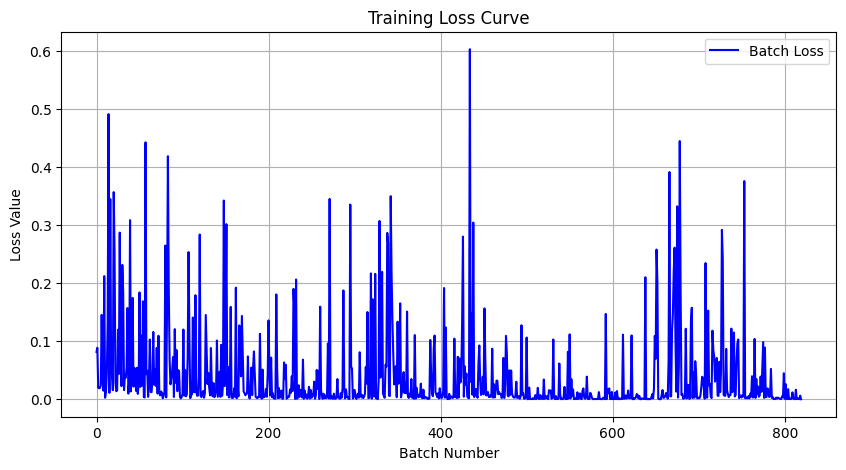

In [22]:
#绘制损失图像
plt.figure(figsize=(10,5))
plt.plot(loss_list, label='Batch Loss', color='blue')
plt.xlabel('Batch Number')
plt.ylabel('Loss Value')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
print("test Overall Accuracy:", end="")
model.eval()
test_total = 0
test_correct = 0
class_total = [0, 0, 0]
class_correct = [0, 0, 0]

with torch.no_grad():
    for x, y in test_loader1:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        _, predicted = torch.max(pred, 1)

        test_total += y.size(0)
        test_correct += (predicted == y).sum().item()

        for label, p in zip(y, predicted):
            label = label.item()
            p = p.item()
            class_total[label] += 1
            if label == p:
                class_correct[label] += 1

total_acc = 100 * test_correct / test_total
print(f"{total_acc:.3f}%")

for i, cls_name in enumerate(class_names):
    if class_total[i] == 0:
        print(f"Category Accuracy :    {cls_name} : 0.000 %")
    else:
        cls_acc = 100 * class_correct[i] / class_total[i]
        print(f"Category Accuracy :    {cls_name} : {cls_acc:.3f} %")


test Overall Accuracy:98.618%
Category Accuracy :    red : 100.000 %
Category Accuracy :    blue : 97.531 %
Category Accuracy :    yellow : 98.113 %


In [24]:
loss_list1 = []
for epoch in range(epochs):
    model.train()
    num_batches = len(train_loader)
    half_batch = num_batches // 2

    for batch_idx, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        # 1. 前向传播，计算损失
        pred = model(x)
        loss = loss_fn(pred, y)

        # 记录当前批次损失
        loss_list1.append(loss.item())

        
        if batch_idx + 1 == half_batch:
            print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

        # 2. 反向传播 + 参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 本轮最后一个批次损失打印
    print(f"Train Epoch : {epoch+1:<3}        Loss : {loss.item():.6f}")

    # 测试集评估
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in test_loader2:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            test_loss += loss.item()

            _, predicted = torch.max(pred.data, 1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()

    avg_test_loss = test_loss / len(test_loader2)
    test_acc = 100 * test_correct / test_total
    print(f"Test -- Average Loss : {avg_test_loss:.4f}, Accuracy : {test_acc:.3f}\n")


Train Epoch : 1          Loss : 0.000817
Train Epoch : 1          Loss : 0.000314
Test -- Average Loss : 0.4158, Accuracy : 88.571

Train Epoch : 2          Loss : 0.044916
Train Epoch : 2          Loss : 0.002760
Test -- Average Loss : 0.2505, Accuracy : 90.000

Train Epoch : 3          Loss : 0.000128
Train Epoch : 3          Loss : 0.000812
Test -- Average Loss : 0.2840, Accuracy : 87.857

Train Epoch : 4          Loss : 0.001602
Train Epoch : 4          Loss : 0.000378
Test -- Average Loss : 0.1096, Accuracy : 93.571

Train Epoch : 5          Loss : 0.006002
Train Epoch : 5          Loss : 0.001255
Test -- Average Loss : 0.1541, Accuracy : 96.429



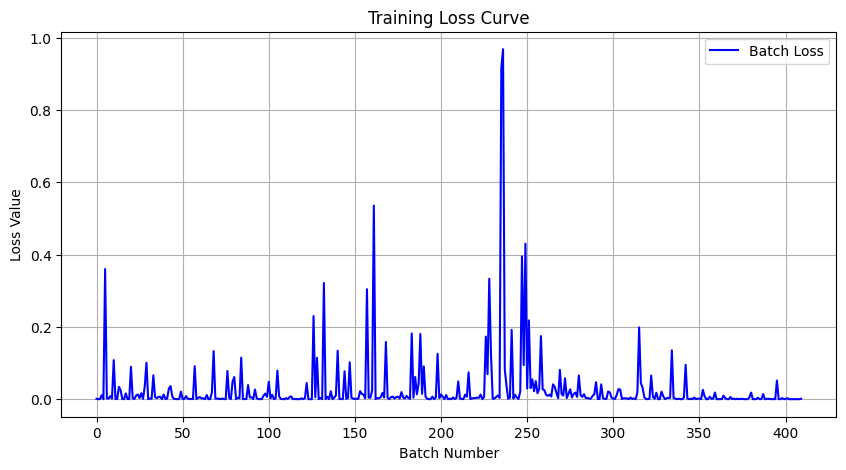

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(loss_list1, label='Batch Loss', color='blue')
plt.xlabel('Batch Number')
plt.ylabel('Loss Value')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


In [26]:
print("test Overall Accuracy:", end="")
model.eval()
test_total = 0
test_correct = 0
class_total = [0, 0, 0]
class_correct = [0, 0, 0]

with torch.no_grad():
    for x, y in test_loader2:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        _, predicted = torch.max(pred, 1)

        test_total += y.size(0)
        test_correct += (predicted == y).sum().item()

        for label, p in zip(y, predicted):
            label = label.item()
            p = p.item()
            class_total[label] += 1
            if label == p:
                class_correct[label] += 1

total_acc = 100 * test_correct / test_total
print(f"{total_acc:.3f}%")

for i, cls_name in enumerate(class_names):
    if class_total[i] == 0:
        print(f"Category Accuracy :    {cls_name} : 0.000 %")
    else:
        cls_acc = 100 * class_correct[i] / class_total[i]
        print(f"Category Accuracy :    {cls_name} : {cls_acc:.3f} %")


test Overall Accuracy:96.429%
Category Accuracy :    red : 100.000 %
Category Accuracy :    blue : 95.918 %
Category Accuracy :    yellow : 92.683 %
